# 01 · From columns to markers

Steps 5 to 10 of Stage 1's sixteen.

| | |
|---|---|
| **Step 5** | Open the table, and look at its structure |
| **Step 6** | Parse the column names into channel and round |
| **Step 7** | **Rename the features with their markers** |
| **Step 8** | Tidy the cell metadata |
| **Step 9** | Decide what to drop |
| **Step 10** | Save the slim table |

Step 7 is the one that matters. Everything before it prepares for it; everything after
it is only possible because of it.

:::{important}
Here we compute, the most important part of the pre-processing, as we give each feature the correct marker name.

This step could be one of the most memory intensive, however most of the time one does not need to load the whole X matrix, which contains all the data values. 
This notebook works mainly on metadata; therefore, one only needs to load this. If you want to do this, one can load the anndata object using the `backed` option, so it is never in memory. 
:::

The table arrives as raw as it gets — no layers, no embeddings, and a `var` holding
4,464 strings and nothing else. By the end of Step 10 it is annotated, a third of the
size, and ready to work on.

In [1]:
import sys
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import decode, layout, panels, plotting
from mcs2026.config import H5AD_FULL, H5AD_SLIM, LAYOUT_XLSX

plotting.set_style()
pd.set_option("display.width", 140)

## Step 5 · Open the table, and look at its structure

```{image} ../../images/feature_table_anatomy_light.svg
:class: only-light
:alt: The AnnData object: a 733,556 by 4,464 matrix X, an obs table of 12 per-cell columns, and a var table holding 4,464 names and no columns at all.
```
```{image} ../../images/feature_table_anatomy_dark.svg
:class: only-dark
:alt: The AnnData object: a 733,556 by 4,464 matrix X, an obs table of 12 per-cell columns, and a var table holding 4,464 names and no columns at all.
```

### Open it backed

`backed="r"` reads the metadata and leaves the matrix on disk. `obs`, `var` and the
shape come back immediately; `X` is a lazy handle you only pay for when you slice it.

This is the habit worth taking away: **look before you load.**

In [2]:
adata = sc.read_h5ad(H5AD_FULL, backed="r")
adata

AnnData object with n_obs × n_vars = 733556 × 4464 backed at '/cluster/home/maaraujo/data_mcs2026/1_FE_pooled1.h5ad'
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Barcode', 'Path', 'ABs', 'Medium', 'Concentration', 'Cell_line', 'Organoid_ID'

In [3]:
print(f"{adata.n_obs:,} cells x {adata.n_vars:,} features")
print(f"dense float32 in memory: {adata.n_obs * adata.n_vars * 4 / 1e9:.1f} GB")
print(f"var columns: {list(adata.var.columns)}   <- empty")

733,556 cells x 4,464 features
dense float32 in memory: 13.1 GB
var columns: []   <- empty


## Step 6 · Parse the column names into channel and round

:::{admonition} How it works

:class: dropdown
The names follow a grammar:

```text
cells_Intensity_mean_intensity_Texas Red_0
      |-family-||--statistic--||-channel-||round|

cells_Texture_Haralick-Mean-contrast-2_Cy5_24
cells_Morphology_area_18                      <- no channel
cells_Population_n_neighbours_radius_300_4    <- no channel
```

Two families carry a channel, because they measure a stain. Two do not, because they
measure the segmentation mask itself.
:::


In [4]:
var = decode.parse_var_names(adata.var_names)
var.head()

,family,statistic,channel,round
feature,,,,
cells_Intensity_max_intensity_Cy5_0,Intensity,max_intensity,Cy5,0
cells_Intensity_max_intensity_DAPI_0,Intensity,max_intensity,DAPI,0
cells_Intensity_max_intensity_FITC_0,Intensity,max_intensity,FITC,0
cells_Intensity_max_intensity_Texas Red_0,Intensity,max_intensity,Texas Red,0
cells_Intensity_mean_intensity_Cy5_0,Intensity,mean_intensity,Cy5,0


In [5]:
unparsed = var.index[var.family.isna()]
print(f"names that did not parse: {len(unparsed)}")
assert len(unparsed) == 0, f"decoder does not cover: {list(unparsed[:5])}"

names that did not parse: 0



### What the matrix is actually made of

In [6]:
decode.structure_report(var)

,columns,statistics,rounds,channels,share
family,,,,,
Texture,3364,58,18,4,75.4%
Population,414,23,18,0,9.3%
Morphology,396,22,18,0,8.9%
Intensity,290,5,18,4,6.5%


**Texture is three-quarters of the table.** 52 Haralick features plus 6 Laws texture
energies, per channel, per round. Haralick features describe how intensity is
*arranged* within a cell — whether a signal is smooth or punctate, clustered or
uniform. For organelle markers that is exactly the interesting part: a lysosome marker
is not informative because it is bright, but because it is *speckled*.
:::{important}
However, taken into account that `Haralick features` and `Laws Texture Energies` are extremely hard to interpret. Therefore, we will provide an anndata object with and without these features for your analysis.

**Intensity is only 6.5%** — the five familiar summary statistics per channel-round.

**Morphology and Population appear once per round** — 18 copies each, describing the
same cells. Whether they were re-measured or merely copied is a question we settle with
one line of code below, and the answer decides whether they are a quality signal or
dead weight.

## Step 7 · Rename the features with their markers

**This is the step the whole of Stage 1 exists for.** Each column name gives a channel
and a round; the staining sheet from [Step 3](00_what_you_are_given.ipynb) says which
antibody that was. Join the two and 3,654 anonymous columns acquire a name.

```{image} ../../images/feature_rename_light.svg
:class: only-light
:alt: A column name split into family, statistic, channel and round; the channel and round are looked up in the staining sheet, which returns the marker Foxo3a.
```
```{image} ../../images/feature_rename_dark.svg
:class: only-dark
:alt: A column name split into family, statistic, channel and round; the channel and round are looked up in the staining sheet, which returns the marker Foxo3a.
```

In [7]:
stainings = layout.read_stainings(LAYOUT_XLSX)
var = decode.annotate(adata.var_names, stainings)
var.sample(6, random_state=0)[["family", "statistic", "channel", "round", "marker", "theme"]]

,family,statistic,channel,round,marker,theme
feature,,,,,,
cells_Texture_Haralick-Range-sum-avg-2_DAPI_14,Texture,Haralick-Range-sum-avg-2,DAPI,14,DAPI,NaN
cells_Morphology_orientation_18,Morphology,orientation,None,18,NaN,morphology
cells_Texture_Haralick-Range-entropy-5_Cy5_28,Texture,Haralick-Range-entropy-5,Cy5,28,Integrin-b1,NaN
cells_Texture_LTE_LE_DAPI_19,Texture,LTE_LE,DAPI,19,DAPI,NaN
cells_Texture_Haralick-Mean-entropy-5_Cy5_20,Texture,Haralick-Mean-entropy-5,Cy5,20,E-cadherin,mechanics
cells_Texture_Haralick-Mean-sum-of-squares-2_DAPI_0,Texture,Haralick-Mean-sum-of-squares-2,DAPI,0,DAPI,NaN


### Check the join is total — in both directions

In [8]:
report = decode.check(var, stainings)
for key, value in report.items():
    print(f"  {key:38s} {value}")

  features                               4464
  channel_round_combinations             58
  combinations_in_sheet_without_data     []
  features_with_a_marker                 3654
  failed_stain_features                  126
  reference_dapi_features                1134
  structural_features                    810


`decode.check` asserts two things, and both matter:

1. **Nothing in the data that the sheet cannot name.** A `(channel, round)` with no
   antibody would mean the sheet is incomplete, and any marker-based analysis would
   have a hole in it.
2. **Nothing in the sheet without data.** An antibody listed but never measured would
   mean a marker silently missing from every panel.

Both sets are empty. 58 channel-round combinations, all accounted for.

## Step 8 · Tidy the cell metadata

`obs` needs work too. Two of its columns are actively misleading.

In [10]:
for column in ["Medium", "Concentration", "Cell_line", "Barcode", "ABs"]:
    print(f"{column:15s} {adata.obs[column].nunique():>3} levels  "
          f"{list(adata.obs[column].unique()[:5])}")

Medium           18 levels  ['Cnd17', 'Cnd12', 'Cnd4', 'Cnd6', 'Cnd13']
Concentration     4 levels  ['36h', '48h', '60h', '84h']
Cell_line         1 levels  ['CBA']
Barcode           1 levels  ['HNES1-MP-PL-1']
ABs               1 levels  ['Ab1']


:::{warning}
**`Concentration` is not a concentration. It holds `'36h'`, `'48h'`, `'60h'`, `'84h'` —
it is the timepoint.**

A column whose name says one thing and whose contents say another is a bug waiting to
happen: someone will eventually treat it as a dose. Rename it now, while you are
looking at it.
:::

In [11]:
obs = adata.obs.copy()

# Timepoint: strip the 'h', and make it an ORDERED categorical so that plots and
# groupbys put 36 before 84 rather than sorting it as text.
obs["timepoint_h"] = pd.Categorical(
    obs["Concentration"].astype(str).str.rstrip("h").astype(int),
    categories=[36, 48, 60, 84], ordered=True,
)

# Condition: swap the Cnd codes for compound names, and make DMSO the FIRST level so
# every default comparison is against the vehicle control.
compounds = layout.read_conditions(LAYOUT_XLSX).set_index("condition_code")["compound"]
ordered = ["DMSO", "PBS"] + sorted(set(compounds) - {"DMSO", "PBS"})
obs["condition"] = pd.Categorical(
    obs["Medium"].map(compounds), categories=ordered, ordered=False
)
obs["condition_code"] = obs["Medium"].astype(str)

# Well position, for plate maps and for testing at the right unit.
obs["well"] = obs["well_name"].astype(str)
obs["row"] = obs["well"].str[0]
obs["column"] = obs["well"].str[1:].astype(int)

obs[["well", "row", "column", "condition", "timepoint_h"]].head()

,well,row,column,condition,timepoint_h
Organoid_ID,,,,,
HNES1-MP-PL-1-B02-0,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-1,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-2,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-3,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-4,B02,B,2,PBS,36


Four columns hold exactly one value each. They are provenance — true of the whole
experiment, not of any particular cell — so they belong in `uns`, not in a
733,556-row column.

In [15]:
provenance = {c: adata.obs[c].unique()[0] for c in ["Barcode", "Cell_line", "ABs", "Path"]}

#### Dropping columns that are now in provenance or that we cleaned up
Now we need to drop the columns that are always constant (we placed them in provenance, which will be in uns['provenance'] in the anndata). We also remove the columns that had original naming, and that we have now tidied up.

In [19]:
obs = obs.drop(columns=["Barcode", "Cell_line", "ABs", "Path", "Medium", "Concentration"])
print("obs columns now:", list(obs.columns))

obs columns now: ['label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column']


### Sanity check against the plate layout

The layout workbook says which condition is in which well. `obs` says so too, from a
completely separate route. They must agree — and if they do not, something is wrong
with the plate map or with the image-to-well assignment, and nothing downstream is
trustworthy.

In [20]:
wells = layout.read_wells(LAYOUT_XLSX)
from_obs = obs.groupby("well", observed=True)["condition_code"].first()
from_sheet = wells.set_index("well")["condition_code"]

shared = from_obs.index.intersection(from_sheet.index)
mismatched = shared[from_obs[shared].values != from_sheet[shared].values]
print(f"wells in obs: {len(from_obs)} | in sheet: {len(from_sheet)} | shared: {len(shared)}")
print(f"conditions disagreeing: {len(mismatched)}")
assert len(mismatched) == 0, f"layout and obs disagree on {list(mismatched[:5])}"

wells in obs: 224 | in sheet: 224 | shared: 224
conditions disagreeing: 0


## Step 9 · Decide what to drop

This is the part that actually makes the file smaller, and the part where you have to
think. Every drop below is a decision with a reason, not a default.

### The two failed stains

From chapter 00: PDGFRα in round 0 and Integrin β1 in round 28 are marked `failed`.
Their columns are still here, still full of numbers.

In [21]:
var[var.failed].groupby(["marker", "round", "channel"], observed=True).size().rename("columns")

marker       round  channel
Integrin-b1  28     Cy5        63
PDGFRa       0      Cy5        63
Name: columns, dtype: int64

### Morphology and Population, repeated 18 times

These describe the segmentation mask — area, eccentricity, how many neighbours a cell
has. They do not depend on which antibody was used, so there is no obvious reason to
measure them 18 times.

Below we check if they are identical

In [22]:
area_columns = var.loc[
    var.index[(var.family == "Morphology") & (var.statistic == "area")]
].sort_values("round").index
area = adata[:, list(area_columns)].to_memory().X

identical = (area == area[:, :1]).all(axis=0)
pd.DataFrame({
    "round": var.loc[area_columns, "round"].astype(int).values,
    "median_area": np.median(area, axis=0),
    "identical_to_round_0": identical,
}).set_index("round").T

round,0,1,2,3,4,8,14,15,17,18,19,20,21,22,24,25,27,28
median_area,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0,2758.0
identical_to_round_0,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


**Byte-identical in all 18 rounds.** the exact same numbers.

Keeping one round is lossless, and drops 765 columns.

### DAPI is a different story

DAPI is also in every round, and it would be easy to wave it away the same way. Do the
same check before deciding.

In [23]:
dapi_columns = var.loc[
    var.index[(var.family == "Intensity")
              & (var.statistic == "mean_intensity")
              & (var.channel == "DAPI")]
].sort_values("round").index
dapi = adata[:, list(dapi_columns)].to_memory().X

dapi_by_round = pd.Series(
    np.median(dapi, axis=0),
    index=var.loc[dapi_columns, "round"].astype(int).values,
    name="median DAPI intensity",
)
print("identical to round 0:", int((dapi == dapi[:, :1]).all(axis=0).sum()), "of", dapi.shape[1])
dapi_by_round

identical to round 0: 1 of 18


0     651.123535
1     617.663208
2     654.008667
3     694.983643
4     725.123413
8     870.251038
14     54.325378
15     47.606640
17    124.265640
18    172.833862
19    145.769089
20    139.832123
21    133.227051
22    131.531006
24    133.230743
25    153.473877
27    167.496262
28    179.924866
Name: median DAPI intensity, dtype: float32

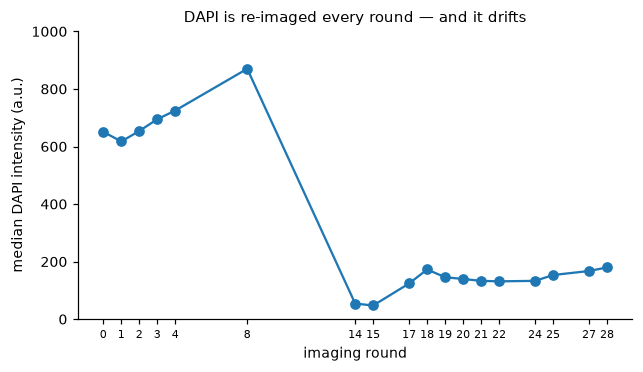

In [24]:
ax = dapi_by_round.plot(marker="o", figsize=(6.5, 3.4))
ax.set(xlabel="imaging round", ylabel="median DAPI intensity (a.u.)",
       title="DAPI is re-imaged every round — and it drifts")
ax.set_ylim(0, dapi_by_round.max() * 1.15)
ax.set_xticks(dapi_by_round.index)
ax.tick_params(axis="x", labelsize=7)

In [25]:
print(f"rounds 0-8:    median {dapi_by_round.loc[:8].median():.0f}")
print(f"rounds 14-28:  median {dapi_by_round.loc[14:].median():.0f}")
print(f"largest step:  round 8 -> 14, {dapi_by_round.loc[8] / dapi_by_round.loc[14]:.0f}x drop")

rounds 0-8:    median 674
rounds 14-28:  median 137
largest step:  round 8 -> 14, 16x drop


DAPI is genuinely re-measured, and it moves a *long* way: the median falls about
fifteen-fold between round 8 and round 14, then settles at roughly a quarter of where
it started. Note where that step is — exactly the gap where rounds 5 to 13 are missing
from the panel. Something changed about the imaging between those sessions.

The nuclei did not change. The measurement did.

Two consequences, and they shape everything after this notebook:

**1. Keep the per-round DAPI intensity.** It is 90 columns, and it is the record of
how staining and imaging drifted. Throwing it away would discard the only evidence of
this problem. (DAPI *texture* is a different matter — 1,044 columns of chromatin
arrangement in a reference channel. One round is plenty.)

**2. Intensities from different rounds are not comparable.** A marker imaged in round
15 and one imaged in round 0 sit on different scales for reasons that have nothing to
do with biology. Any analysis that puts them side by side — a heatmap across markers,
a PCA over the whole panel — is partly measuring the round.

:::{important}
This is why chapter 02 normalises **within round, against the DMSO controls**, rather
than z-scoring the whole matrix at once. The design puts control wells in every round,
which is what makes the correction possible.
:::

### Apply the decisions to reduce our matrix

In [26]:
keep = decode.slim_mask(
    var,
    keep_structural_round=0,        # verified identical above: lossless
    keep_dapi_intensity=True,       # the drift record, 90 columns
    keep_dapi_texture_round=0,      # chromatin texture in the reference channel
    drop_failed=True,               # the two stains that did not work
    drop_texture=False,             # keep Haralick
)
decode.slim_report(var, keep, adata.n_obs)

,stage,features,GB_float32
0,as loaded,4464,13.10
1,after slimming,2587,7.59


In [27]:
dropped = var[~keep]
pd.Series({
    "failed stains": int(dropped.failed.sum()),
    "duplicate morphology / population": int(dropped.is_structural.sum()),
    "DAPI texture beyond round 0": int((dropped.is_reference & (dropped.family == "Texture")).sum()),
    "total dropped": len(dropped),
}, name="columns")

failed stains                         126
duplicate morphology / population     765
DAPI texture beyond round 0           986
total dropped                        1877
Name: columns, dtype: int64

:::{admonition} If your session is still too small
:class: tip

`drop_texture=True` removes the 3,364 texture columns and takes the table under 1 GB.
You lose the sub-cellular structure that the organelle panel is largely about, so it is
a real cost but makes your data much smaller as texture features are 75% of your anndata.
:::

## Step 10 · Save the slim table

:::{note}
**This is the first of three cuts, not the only one.** 2,587 columns is small enough to
store and too large to analyse: 2,262 of them are texture, and a method handed all of them
describes texture. [Step 19](03_normalisation.ipynb) cuts to the **38** marker mean
intensities and shows why, and
[chapter 07](../2_controls/07_umap.ipynb) cuts again to **8** for everything that builds a
neighbour graph.

Each cut is a decision with evidence attached. This one is the only one that is provably
lossless — the others trade something, and say what.
:::

Only now do we read pixels off disk — and only the columns we decided to keep.

In [28]:
slim = adata[:, keep.values].to_memory()
slim.obs = obs
slim.var = var[keep].copy()
slim.uns["provenance"] = provenance
slim.uns["decode_report"] = {k: str(v) for k, v in report.items()}
slim

AnnData object with n_obs × n_vars = 733556 × 2587
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme'
    uns: 'provenance', 'decode_report'

In [ ]:
slim.write_h5ad(H5AD_SLIM, compression="gzip")
print(f"wrote {H5AD_SLIM}")
print(f"  {slim.n_obs:,} cells x {slim.n_vars:,} features")
print(f"  {slim.n_obs * slim.n_vars * 4 / 1e9:.2f} GB in memory "
      f"(was {adata.n_obs * adata.n_vars * 4 / 1e9:.1f} GB)")

### What Step 7 bought you

`var` is no longer a list of strings. It is a table you can ask questions of:

In [29]:
slim.var.groupby("theme", observed=True).agg(
    columns=("marker", "size"), markers=("marker", "nunique")
).sort_values("columns", ascending=False)

,columns,markers
theme,,
signaling,567,9
identity,504,8
mechanics,504,8
metabolism,315,5
organelles,315,5
cell_cycle,189,3
population,23,0
morphology,22,0


In [50]:
theme_name = "mechanics"

# Get the list of marker names for that theme
markers = slim.var.loc[slim.var["theme"] == theme_name, "marker"]

# As a plain list
marker_names = markers.unique().tolist()
print(marker_names)

['p-MyosinIIa', 'ZO-1', 'a-Tubulin', 'E-cadherin', 'Fibronectin', 'LAMA4', 'LaminA', 'LaminB1']


---

## Summary
### 1. We cleaned the data by:
#### 1.1 Relabelling metada columns in obs

That allows easy access to well names, conditions and timepoints


In [56]:
slim.obs[["well", "row", "column", "condition", "timepoint_h"]].head()

,well,row,column,condition,timepoint_h
Organoid_ID,,,,,
HNES1-MP-PL-1-B02-0,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-1,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-2,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-3,B02,B,2,PBS,36
HNES1-MP-PL-1-B02-4,B02,B,2,PBS,36


#### 1.2 Giving features proper marker names

In [57]:
slim.var.sample(6, random_state=0)[["family", "statistic", "channel", "round", "marker", "theme"]]

,family,statistic,channel,round,marker,theme
feature,,,,,,
cells_Intensity_std_intensity_DAPI_27,Intensity,std_intensity,DAPI,27,DAPI,NaN
cells_Texture_Haralick-Range-contrast-5_Cy5_22,Texture,Haralick-Range-contrast-5,Cy5,22,Fibronectin,mechanics
cells_Intensity_sum_intensity_Cy5_3,Intensity,sum_intensity,Cy5,3,Sox2,identity
cells_Intensity_std_intensity_Texas Red_2,Intensity,std_intensity,Texas Red,2,GATA6,identity
cells_Intensity_min_intensity_DAPI_18,Intensity,min_intensity,DAPI,18,DAPI,NaN
cells_Texture_Haralick-Range-diff-entropy-2_Cy5_27,Texture,Haralick-Range-diff-entropy-2,Cy5,27,LaminA,mechanics


#### 1.3 Moved constants that were in obs and reports off pre-processing to uns

In [63]:
slim.uns # contains constants and report info

AnnData object with n_obs × n_vars = 733556 × 2587
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme'
    uns: 'provenance', 'decode_report'

#### 1.4 Dropped unnecesary columns
Such as the repeat measurement of morphology and texture of DAPI on all rounds and failed stainings

------

## The Next step
An example of the importance of normalisation:
#### Cells per well

<Axes: title={'center': 'Cells per well'}>

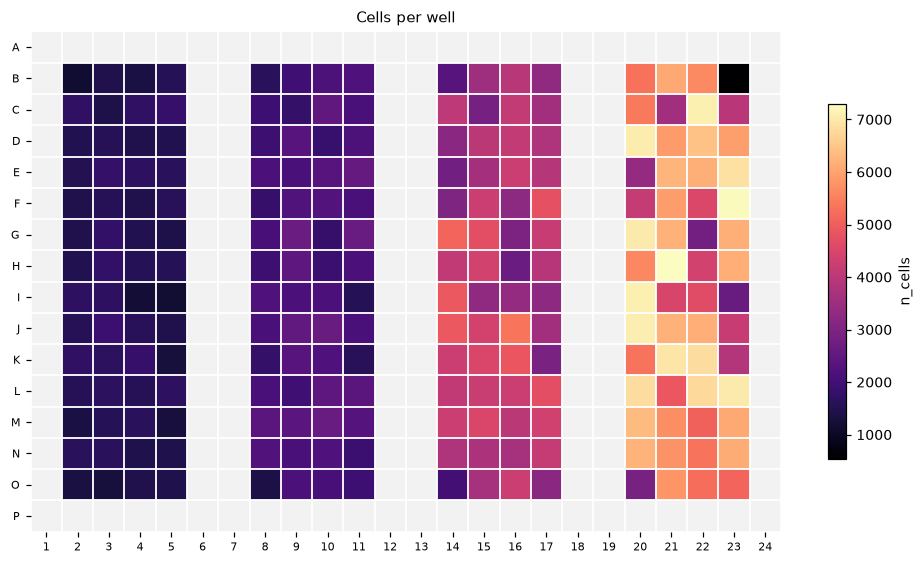

In [64]:
counts = (slim.obs.groupby("well", observed=True)
          .size().rename("n_cells").reset_index())
counts["row"] = counts.well.str[0]
counts["column"] = counts.well.str[1:].astype(int)
plotting.plate_map(counts, "n_cells", cmap="magma", title="Cells per well")

:::{admonition} Explained
:class: dropdown
Cell number is itself a phenotype — a compound that kills cells or blocks division
gives fewer. So structure here is expected and interesting.

The trap is that condition and row are confounded by design. A smooth gradient down the
plate could be an edge or pipetting artefact rather than biology, and you cannot
separate the two from this plate alone. Chapter 02 checks the controls specifically,
because DMSO wells appear in every row and so give a position readout at fixed
treatment.
:::

---

**Next:** [02 · QC and normalisation](02_quality_control.ipynb) — border cells,
staining thresholds, plate effects, and measuring everything against DMSO.